# Agentic RAG

RAG Agent는 Retriever를 Tool로 등록해서 Agent가 **검색 여부를 판단**한다. 하지만 검색 자체는 여전히 1회성이다. 검색 결과가 부정확해도 그대로 답변에 사용하고, 쿼리가 검색에 부적합해도 수정 없이 넘긴다.

Agentic RAG는 **검색 파이프라인 자체**를 에이전트화한다. 검색 결과를 평가하고, 부족하면 쿼리를 재작성해서 다시 검색하고, 답변 생성 후에도 자체 검증을 거친다. 즉, 검색 → 평가 → 재시도의 **자율적인 루프**를 구성하는 것이 핵심이다.

| 구분 | RAG Agent | Agentic RAG |
|----|-----------|-------------|
| 핵심 아이디어 | Agent가 RAG를 **도구로 사용** | RAG 흐름 자체가 **에이전트화** |
| 검색 횟수 | 보통 1회 | 필요에 따라 반복 |
| 자율성 | Agent 레벨에서 결정 (검색 여부) | 검색 레벨에서도 자율 판단 (쿼리 재작성, 관련성 평가) |
| 쿼리 수정 | 사용자 질문 그대로 | 동적으로 재작성 |
| 적합한 상황 | 단순 질문, 빠른 응답 | 복잡한 질문, 높은 정확도 |

In [1]:
from dotenv import load_dotenv

load_dotenv()

True

## 실습: Agentic RAG 구현

Reflection 패턴의 "자기 평가 → 수정 → 재시도" 루프를 RAG 파이프라인에 적용한다.

구현할 그래프 구조:

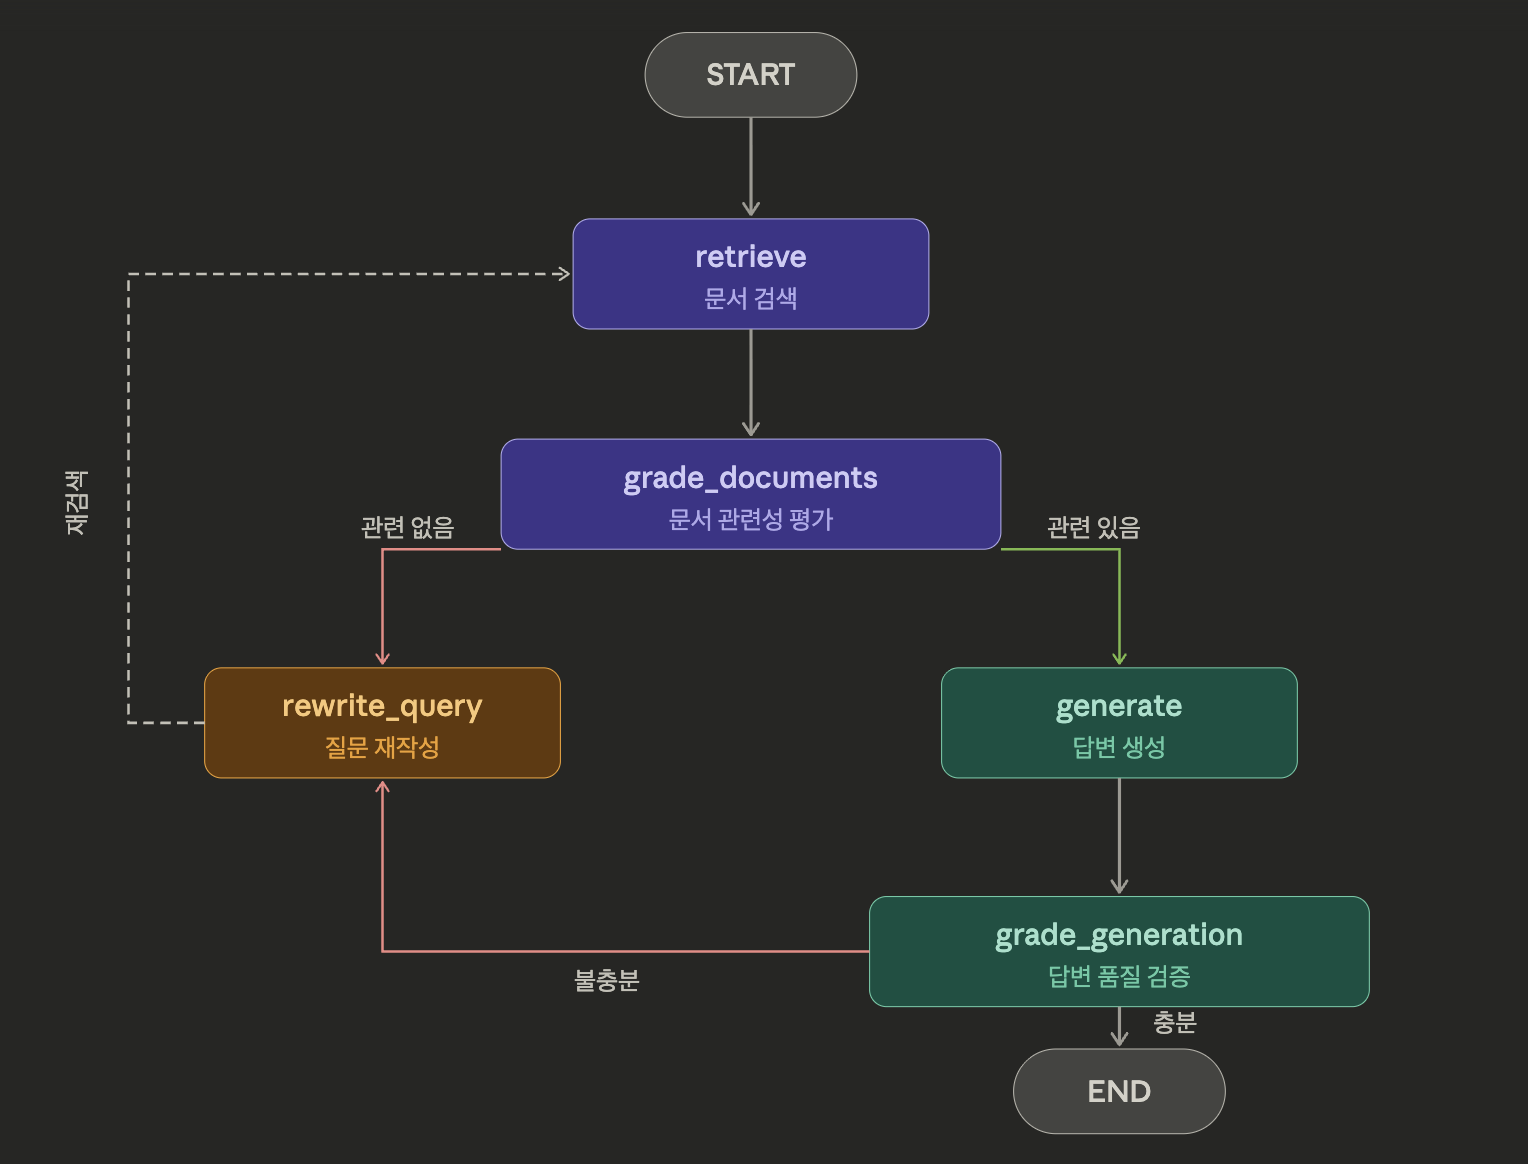

State 필드:
- `question`: 현재 질문 (재작성될 수 있음)
- `documents`: 검색된 문서
- `generation`: 생성된 답변
- `citations`: 답변의 근거가 된 문서 원문 발췌
- `relevance`: 문서 관련성 평가 결과 (bool)
- `is_sufficient`: 답변 품질 검증 결과 (bool)
- `retry_count`: 재시도 횟수 (무한 루프 방지)

In [5]:
## 인덱싱 코드
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings
from langchain_community.document_loaders import PyPDFLoader, DirectoryLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
import chromadb

COLLECTION_NAME = "spri_ai_brief_prac"  # 컬렉션 이름 (RDB의 테이블에 해당)
PERSIST_DIR = "./chroma_db"  # 저장 폴더 경로 (RDB의 데이터베이스에 해당)
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

# 문서 로드 → 분할
loader = DirectoryLoader(
    "data/", 
    glob="**/*SPRI*.pdf", 
    loader_cls=PyPDFLoader
)
docs = loader.load()

splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
chunks = splitter.split_documents(docs)

print(f"총 {len(chunks)}개 청크를 벡터 DB에 저장합니다...")
# 기존 컬렉션이 있으면 삭제 (중복 방지)
client = chromadb.PersistentClient(path=PERSIST_DIR)
if COLLECTION_NAME in [c.name for c in client.list_collections()]:
    client.delete_collection(COLLECTION_NAME)

# 벡터 스토어 생성 + 문서 저장
vectorstore = Chroma.from_documents(
    documents=chunks,
    embedding=embeddings,
    collection_name=COLLECTION_NAME,
    persist_directory=PERSIST_DIR,
    
)

print("저장 완료!")

총 222개 청크를 벡터 DB에 저장합니다...
저장 완료!


In [ ]:
from typing import Annotated, List, TypedDict
# 1. 그래프의 '뼈대'와 '흐름' (도화지와 선)
from langgraph.graph import StateGraph, END, START
# 2. 채팅 모델과 프롬프트 (두뇌와 대화법)
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
# 3. 데이터 구조화 (보고서 양식 - Pydantic)
from pydantic import BaseModel, Field


"""
에이전트 빌드업 로드맵 & 학습 파일 매칭 가이드
1. [준비] 필수 라이브러리 및 환경 변수 임포트 
   └─  힌트: 11, 13번 파일 상단 참고
2. [설계도] 에이전트의 공용 장바구니(GraphState) 정의 
   └─  힌트: 11, 13번 파일 (TypedDict 구조와 Annotated 사용법 확인)
3. [보고서] 답변 및 평가용 정형 데이터(Pydantic) 양식 만들기 
   └─  힌트: 04번 파일 (Structured Output 설계 시 필수!)
"""


class Prac_state (TypedDict):
    question : str          # 질문
    documents : List[str]   # 검색된 문서
    generation : str        # 생성된 답변
    citations : List[str]   # 답변의 근거 문서
    relevance : bool        # 문서 관련성 평가
    is_sufficient : bool    # 답변 품질 결과
    retry_count : Annotated[int, Field(default=0)]  #무한루프 방지용

class GradeDocuments(BaseModel):
    """찾아온 문서와 사용자의 질문과의 관련성을 0~10점으로 채점하는 양식"""
    relevance_score: int = Field(
        description="사용자 질문과 문서의 관련성 점수 (0: 무관, 10: 완벽 일치)"
    )
    rationale: str = Field(
        description="왜 이 점수를 부여했는지 문서의 핵심 내용을 근거로 설명하세요."
    )
    is_useful: bool = Field(
        description="점수가 6점 이상이면 True, 아니면 False를 입력하세요."
    )

class GradeAnswer(BaseModel):
    """답변이 정확한지, 그리고 충분한지 검토하는 채점표."""
    is_sufficient: bool = Field(
        description="사용자질문에 대한 만족스러울만한 답변이 맞는가? (true/false)"
    )





In [8]:
"""
4. [검색] 외부 문서 저장소(Vector DB) 연결 및 리트리버 설정
   └─  힌트: 07, 08번 파일 (Vector DB 로드 및 Retriever 생성)
5. [두뇌] 각 단계별 프롬프트(질문/평가/수정) 템플릿 생성
   └─  힌트: 01, 02번 파일 (Role 부여 및 제약 사항 설정)
    """
COLLECTION_NAME = "spri_ai_brief_prac"
PERSIST_DIR = "./chroma_db"


retriever = vectorstore.as_retriever(search_kwargs={"k": 4})

# 문서 검증 프롬프트
doc_grader_prompt = ChatPromptTemplate.from_messages(
    [(
        "system",
        """너는 사용자 질문과 검색된 문서 간의 관련성을 평가하는 전문 채점관이야.   

            [평가 규칙]
            1. 제공된 '문서' 내용이 사용자의 '질문'과 조금이라도 관련이 있다면 관련이 있는 것으로 간주해.
            2. 관련성을 0점에서 10점 사이의 점수로 매겨줘. (0: 전혀 무관, 10: 완벽 일치)
            3. 점수가 6점 이상이라면 'is_useful'을 True로, 그 미만이라면 False로 설정해.
            4. 왜 그런 점수를 줬는지 '문서의 핵심 내용'을 근거로 'rationale'에 짧게 설명해줘.
            반드시 지정된 양식에 맞춰서 답변해야 해."""),(
            "human", "사용자 질문: {question} \n\n 검색된 문서 내용: {context}"
        ),
    ]
)
# 답변 프롬프트
rag_chain_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """너는 AI 산업 기술 동향을 분석하고 설명해주는 전문 연구원이야.
            
            [답변 규칙]
            1. 반드시 제공된 '문서(Context)'에 있는 팩트만 바탕으로 답변해.
            2. 문서에 없는 내용을 지어내지 말고, 모르면 모른다고 솔직하게 말해.
            3. 보고서를 읽는 사람에게 전달하듯 전문적이면서도 명확한 말투를 사용해.
            4. 답변 끝에는 참고한 문서의 제목이나 페이지 정보를 언급해줘.
            
            문서 내용: {context}"""
        ),
        (
            "human", 
            "질문: {question}"
        ),
    ]
)

# 답변 검증 프롬프트
answer_grader_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """너는 AI 답변의 정확성을 검토하는 품질 관리자야. 
            생성된 '답변'이 '근거 문서'의 내용과 일치하는지, 그리고 '질문'에 대해 충분한 정보를 담고 있는지 검사해.
            
            [검토 기준]
            1. 답변에 문서에 없는 내용이 포함되어 있다면 'false'.
            2. 질문에 대한 핵심 정보가 빠져있다면 'false'.
            3. 모든 게 완벽하고 정확하다면 'is_sufficient'를 'true'로 설정해."""
        ),
        (
            "human", 
            "근거 문서: {context} \n\n 생성된 답변: {generation} \n\n  질문: {question}"
        ),
    ]
)

# 질문 재생성 하는 프롬프트
transform_query_prompt = ChatPromptTemplate.from_messages(
    [
        (
        "system",
            """너는 사용자의 질문을 분석하여 검색(RAG)이 더 잘 되도록 재작성하는 전문가야.
            
            [미션]
            1. 원래 질문의 핵심 의도는 절대 바꾸지 마.
            2. 검색 엔진이 관련 문서를 더 잘 찾을 수 있도록 '산업용어'나 '핵심 키워드'를 보강해.
            3. 답변은 군더더기 없이 '재작성된 질문' 딱 한 문장만 출력해."""
        ),
        (
            "human", 
            "현재 질문: {question} \n\n 위 질문을 검색에 최적화된 형태로 다시 작성해줘."
        ),
    ]
)

# 1. AI 두뇌 준비
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

# 2. 문서 검증 체인 (Pydantic 양식 연결)
# .with_structured_output을 써서 아까 만든 GradeDocuments 양식대로만 답하게 합니다.
doc_grader_chain = doc_grader_prompt | llm.with_structured_output(GradeDocuments)

# 2-1. 질문 재생성 하는 체인

query_rewriter_chain = transform_query_prompt | llm | StrOutputParser()

# 3. 답변 생성 체인 (일반적인 답변)
rag_chain = rag_chain_prompt | llm | StrOutputParser()

# 4. 품질 검증 체인 (Pydantic 양식 연결)
answer_grader_chain = answer_grader_prompt | llm.with_structured_output(GradeAnswer)


In [9]:

"""
6. [행동] 각 노드별 실행 함수(Node Functions) 정의
   └─  힌트: 12, 14번 파일 (ReAct 및 RAG Agent 실행 로직)
      - retrieve: 09번 참고
      - grade_docs: 10번 (검증/평가 로직) 참고
      - rewrite_query: 15번 (질문 변환/라우팅) 참고
"""

def retrieve_node(state : Prac_state) :
    """문서 가져오는 노드"""
    print("--- [Step 1] 문서 검색 중... ---")
    question = state["question"]
    documents = retriever.invoke(question)
    return {"documents" : documents}

def grade_documents_node(state: Prac_state):
    """문서와 질문을 비교하여 적합한 문서를 필터링하는 노드"""
    print("--- [Step 2] 문서 적합성 평가 시작 ---")
    
    question = state["question"]
    documents = state["documents"]
    
    # 1. 합격한 문서만 담을 바구니
    filtered_docs = []
    
    # 2. 모든 문서를 하나씩 검사
    for doc in documents:
        # doc_grader_chain은 GradeDocuments 양식으로 답을 줍니다.
        score = doc_grader_chain.invoke({
            "question": question, 
            "context": doc.page_content
        })
        
        # score.is_useful (True/False) 확인
        if score.is_useful:
            print(f"  - [Pass] 점수: {score.relevance_score} / 사유: {score.rationale}")
            filtered_docs.append(doc)
        else:
            print(f"  - [Fail] 점수: {score.relevance_score} / 사유: {score.rationale}")

    # 3. [중요] 가방(Prac_state)의 변수명 'relevance'에 맞춰서 반환!
    if not filtered_docs:
        print("--- [결과] 쓸만한 문서 없음 -> 질문 재작성으로! ---")
        # 가방 칸 이름인 'relevance'를 사용하고, 값은 bool 타입인 False를 줍니다.
        return {"documents": [], "relevance": False} 
    else:
        print(f"--- [결과] {len(filtered_docs)}개의 관련 문서 확보! ---")
        # 가방 칸 이름인 'relevance'를 사용하고, 값은 bool 타입인 True를 줍니다.
        return {"documents": filtered_docs, "relevance": True}

def transform_query_node(state: Prac_state):
    """검색 결과가 좋지 않을 때 질문을 재작성하여 다시 검색으로 보내는 노드"""
    print("--- [Step 3] 질문 재작성 중... (검색 최적화) ---")
    
    question = state["question"]
    current_retry = state.get("retry_count", 0)

    # 1. LLM에게 질문 재작성 시키기
    better_question = query_rewriter_chain.invoke({"question": question})
    
    print(f"  - [Before] {question}")
    print(f"  - [After] {better_question}")
    
    # 2. 가방의 'question'을 새 질문으로 교체해서 반환!
    # 이렇게 반환하면 이 가방을 들고 다시 'Retrieve 노드'로 돌아가게 됩니다.
    return {"question": better_question,
            "retry_count": current_retry + 1}

def generate_node(state: Prac_state):
    """합격한 문서들을 바탕으로 답변을 생성하는 노드"""
    print("--- [Step 4] 답변 생성 중 (AI 등판) ---")
    
    question = state["question"]
    documents = state["documents"]
    
    # 1. 문서들을 하나의 텍스트로 합치기 (Context 만들기)
    # 리스트 안에 있는 문서들의 내용을 줄바꿈(\n)으로 이어붙입니다.
    context = "\n\n".join([doc.page_content for doc in documents])
    
    # 2. 답변 생성 체인 호출 (StrOutputParser 덕분에 문자열로 바로 나옵니다)
    generation = rag_chain.invoke({"context": context, "question": question})
    
    # 3. 가방의 'generation' 칸에 답변 채워넣기
    return {"generation": generation}

def check_hallucination_node(state: Prac_state):
    """생성된 답변의 품질(환각 여부 및 충분성)을 검증하는 노드"""
    print("--- [Step 5] 답변 품질 검증 (품질 관리자 등판) ---")
    
    question = state["question"]
    documents = state["documents"]
    generation = state["generation"]
    
    # 1. 다시 문서들을 합쳐서 근거 자료로 준비
    context = "\n\n".join([doc.page_content for doc in documents])
    
    # 2. 품질 검증 체인 호출 (GradeAnswer 양식으로 데이터가 옵니다)
    score = answer_grader_chain.invoke({
        "question": question,
        "context": context,
        "generation": generation
    })
    
    # 3. 가방의 'is_sufficient' 칸에 결과 기록 
    return {"is_sufficient": score.is_sufficient}




In [10]:
"""
7. [판단] 다음 단계로 갈지 결정하는 조건부 로직(Conditional Edges) 정의
   └─  힌트: 11, 15번 파일 (if/else 분기 처리 로직)
8. [연결] 도화지(StateGraph) 위에 노드와 엣지 배치하기

"""
### 조건부 로직 정의

# 문서 평가에 따른 분기
def decide_after_grading(state: Prac_state):
    if state["relevance"]:
        return "generate"
    
    if state.get("retry_count", 0) >= 3:
        print("--- [LIMIT] 3회 시도 초과! 종료합니다. ---")
        return "end" # END 지점으로 보냄
        
    return "transform_query"

#답변 평가에 따른 분기
def decide_after_hallucination_check(state: Prac_state):
    # 현재 몇 번째 시도인지 확인
    retry_count = state.get("retry_count", 0)
    
    # 1. 답변이 충분하고 완벽하다면? -> 종료!
    if state.get("is_sufficient"):
        print("--- [SUCCESS] 완벽한 답변 생성 완료! ---")
        return "finish"
    
    # 2. 답변이 부족한데, 이미 3번 넘게 고쳤다면? -> 강제 종료 (브레이크)
    if retry_count >= 3:
        print(f"--- [LIMIT] 답변 재작성 3회 초과 ({retry_count}회). 현재 상태로 종료합니다. ---")
        return "finish" # 또는 "end" (매핑된 이름에 따라)

    # 3. 아직 기회가 남았다면? -> 다시 고치러 가기!
    print(f"--- [RETRY] 답변 품질 미달로 다시 시도합니다. (현재 {retry_count}회) ---")
    return "rewrite"


### 노드 생성 및 연결

# 1. 도화지(StateGraph) 펼치기
workflow = StateGraph(Prac_state)

# 2. 노드 등록
workflow.add_node("retrieve", retrieve_node)
workflow.add_node("grade_documents", grade_documents_node)
workflow.add_node("generate", generate_node)
workflow.add_node("transform_query", transform_query_node)
workflow.add_node("check_hallucination", check_hallucination_node)

# 3. 노드 연결 
workflow.add_edge(START, "retrieve") 
workflow.add_edge("retrieve", "grade_documents")
workflow.add_conditional_edges(
    "grade_documents",
    decide_after_grading,
    {
        "generate": "generate",
        "transform_query": "transform_query",
        "end": END  
    }
)
workflow.add_edge("transform_query", "retrieve")
workflow.add_edge("generate", "check_hallucination")
workflow.add_conditional_edges(
    "check_hallucination",
    decide_after_hallucination_check,
    {
        "finish": END, 
        "rewrite": "transform_query" # 부족하면 다시 고치러
    }
)


app = workflow.compile()


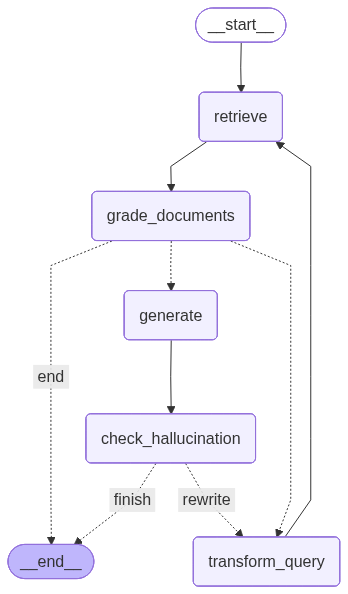

--- [성공] 그래프 시각화 완료! 위 그림을 확인하세요. ---


In [11]:
"""
10. [완성] 그래프 컴파일 및 시각화 확인
    └─  힌트: 11번 파일 (app = workflow.compile() 부분)
"""

from IPython.display import Image, display

try:
    # 그래프를 이미지(PNG) 형태로 불러옵니다.
    # xdot 엔진이 설치되어 있어야 예쁘게 나오지만, 기본으로도 확인 가능해요!
    display(Image(app.get_graph().draw_mermaid_png()))
    print("--- [성공] 그래프 시각화 완료! 위 그림을 확인하세요. ---")
except Exception as e:
    # 환경에 따라 출력이 안 될 경우를 대비한 방어 로직
    print(f"--- [알림] 시각화 실패: {e}")
    print("팁: pygraphviz나 mermaid 관련 라이브러리가 필요할 수 있습니다.")

In [12]:
"""
11. [테스트] 실제 질문 입력 및 '자기 반성' 루프 작동 확인
    └─  힌트: 16번 파일 (Reflection 루프 테스트 방법)
"""

inputs = {
    "question": "AI 주요 소식이 머야 ?", 
}

# 2. 실행 설정 (무한 루프 방지용 50회 제한)
config = {"recursion_limit": 50}

print("\n" + "="*50)
print("🚀 Biz-Fund-AI 에이전트 가동 시작!")
print("="*50 + "\n")

# 3. 실시간 스트리밍 실행
try:
    for output in app.stream(inputs, config=config):
        # output은 {노드이름: {업데이트된 가방내용}} 형태입니다.
        for key, value in output.items():
            print(f"📍 [현재 단계: {key}]")
            
            # 질문이 바뀌었는지 확인 (Rewrite 확인용)
            if "question" in value:
                print(f"🔍 질문 상태: {value['question']}")
            
            # 문서가 몇 개나 통과했는지 확인
            if "documents" in value:
                print(f"📄 확보된 문서 수: {len(value['documents'])}개")
                
            # 답변이 생성됐는지 확인
            if "generation" in value:
                print(f"🤖 생성된 답변: {value['generation'][:100]}...") # 너무 기니까 앞부분만!
            
            # 루프 횟수 확인
            if "retry_count" in value:
                print(f"🔄 시도 횟수: {value['retry_count']}")
            
            print("-" * 30)

except Exception as e:
    print(f"\n 실행 중 에러 발생!")
    print(f"에러 메시지: {e}")
    print("팁: 에러 메시지 상단에 'Step' 로그를 보고 어디서 멈췄는지 확인해 보세요!")

print("\n" + "="*50)
print("✅ 모든 프로세스가 종료되었습니다.")
print("="*50)



🚀 Biz-Fund-AI 에이전트 가동 시작!

--- [Step 1] 문서 검색 중... ---
📍 [현재 단계: retrieve]
📄 확보된 문서 수: 4개
------------------------------
--- [Step 2] 문서 적합성 평가 시작 ---
  - [Pass] 점수: 9 / 사유: 문서 내용은 AI 관련 주요 소식과 기술 발표에 대한 정보를 포함하고 있어 사용자의 질문과 매우 관련이 있습니다.
  - [Pass] 점수: 8 / 사유: 문서에는 AI 관련 주요 소식들이 나열되어 있어, 사용자의 질문인 'AI 주요 소식'과 직접적으로 관련이 있습니다.
  - [Pass] 점수: 7 / 사유: 문서에는 AI 관련 주요 행사와 일정이 나열되어 있어, 사용자의 질문인 'AI 주요 소식'과 관련이 있습니다.
  - [Pass] 점수: 9 / 사유: 문서 내용은 AI와 관련된 다양한 주요 소식들을 다루고 있어, 사용자의 질문인 'AI 주요 소식'과 매우 관련이 깊습니다.
--- [결과] 4개의 관련 문서 확보! ---
📍 [현재 단계: grade_documents]
📄 확보된 문서 수: 4개
------------------------------
--- [Step 4] 답변 생성 중 (AI 등판) ---
📍 [현재 단계: generate]
🤖 생성된 답변: 최근 AI 분야의 주요 소식은 다음과 같습니다:

1. **기술 및 연구**:
   - 구글 딥마인드가 차세대 월드 모델인 '지니 3'를 공개했습니다.
   - 엔비디아는 시그라프...
------------------------------
--- [Step 5] 답변 품질 검증 (품질 관리자 등판) ---
--- [SUCCESS] 완벽한 답변 생성 완료! ---
📍 [현재 단계: check_hallucination]
------------------------------

✅ 모든 프로세스가 종료되었습니다.
